In [1]:
import dill
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from particles.kalman import Kalman
import particles.state_space_models as ssms

from particles_cdssm.core import CDSSM_SMC, SMC
import particles_cdssm.plot as splt
import particles_cdssm.feynman_kac as sfk
from particles_cdssm.cdssm_lib import CDSSM_LIB, build_cdssm
from particles_cdssm.continuous_discrete_ssms import NormalCDSSM, MvNormalCDSSM
import particles_cdssm.auxiliary_bridges as axb

- In run id 100, model `mv_ou`, we have some results for $T=1000$, $N_{FFBS}=4000$ and $N_{genealogy}=10000$ that look okay for the Bootstrap PF
These results exclude Part 3, which involves CD-SSM algorithms 
- In run id 50, model `mv_ou`, we have some results for $T=1000$, $N_{FFBS}=400$ and $N_{genealogy}=1000$ that look okay for CD-SSM algorithms

In [2]:
run_id = '100'
cdssm_str = 'ou'


# Make sure these 2 params are consistent
cdssm_smc = True

# fks = ['Bootstrap']
# fks = ['GuidedPF']
# fks = ['BootstrapDA', 'BsR_DH']
# fks = ['BootstrapDA', 'BsR_DH']
# fks = ['BwG_DH_DBrP', 'BwR_DH_DBrP']
# fks = ['FwG_OUP', 'FwR_DH_OUP']
fks = ['BootstrapDA', 'BwR_DH_DBrP']


df_part_1 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_1.json')
df_part_2 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_2.json')
if cdssm_smc:
    df_part_3 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_3.json')

with open(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

In [3]:
# Work with copies of the original dfs
df_1 = df_part_1.copy()
df_2 = df_part_3.copy() if cdssm_smc else df_part_2.copy()
df_2 = df_2[df_2['fk'].isin(fks)]


# Extract the metadata
cdssm = metadata['cdssm']
lgssm = metadata['lgssm']
x = metadata['x']
y = metadata['y']
T = len(y)
obs_times = metadata['stored_obs_times']
nruns = metadata['nruns']
N_genealogy = metadata['N_genealogy']
N_FFBS_MCMC = metadata['N_FFBS_MCMC']

ext = '' if cdssm.islgssm else '_pf'

print(f'Model: {cdssm_str}, T: {T}, N_genealogy: {N_genealogy}, N_FFBS_MCMC: {N_FFBS_MCMC}')

print(f'Model params: {cdssm.params}')

Model: ou, T: 100, N_genealogy: 100, N_FFBS_MCMC: 100
Model params: {'rho': 1.0, 'mu': 0.0, 'phi': 1.0, 'sigmaY': 1.0}


For running a benchmark for testing `CDSSM_SMC` smoothing algorithms: 

- At `N=1000`, we observe MAEs for `FFBS_MCMC` of around 0.01 (see runid 30) using the GuidedPF.
- At `N=10000`, we observe MAEs for `FFBS_MCMC` of around 0.0004. (see runid 20) using the GuidedPF.
So, we might 

# Plot of the CD-SSM

We plot below the simulation of the CD-SSM of interest. We choose a model such that ratio of observation noise/signal noise is high. The smoothing distribution changes materially as the total number of observations increases. 

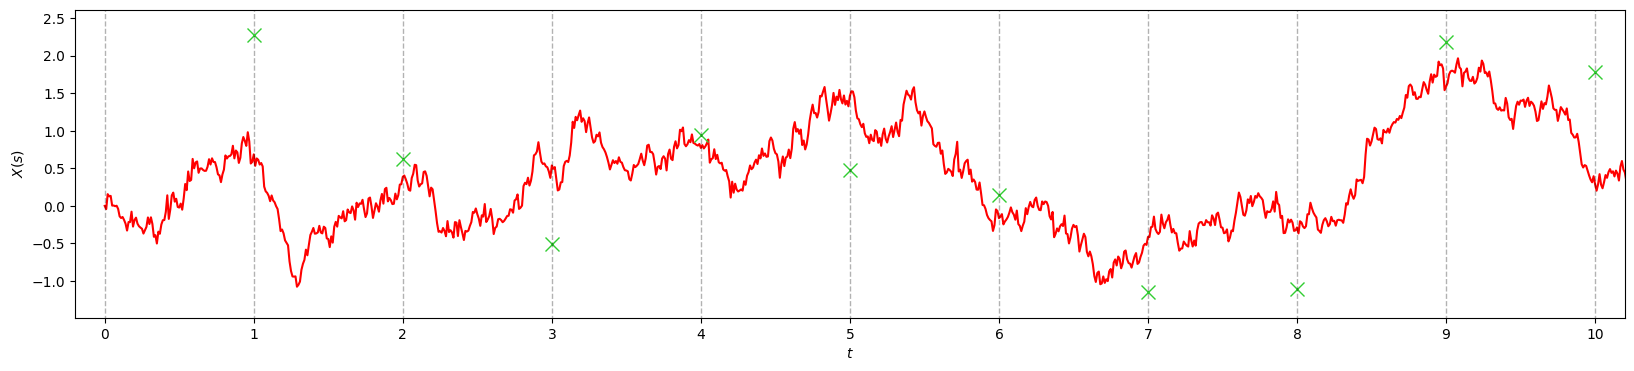

In [4]:
plot_T = 10

x_plt = x[:plot_T + 2]
y_plt = y[:plot_T + 2]

#quantiles = metadata['quantiles']

if isinstance(cdssm, NormalCDSSM): 
    fig, axes = splt.cdssm_simulation_plot(cdssm, x_plt, y_plt)
elif isinstance(cdssm, MvNormalCDSSM):
    fig, axes = splt.mv_cdssm_simulation_plot(cdssm, x_plt, y_plt)
else:
    pass

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax in axes:
    ax.set_xlim((-0.2, plot_T + 0.2))
plt.show()

# Can add custom changes to the fig/axes below:

# Part 1: The true target distributions

## Plot of the true Smoothing Distributions

We plot for each of the stored observations times, the filtering distribution vs the smoothing distribution.

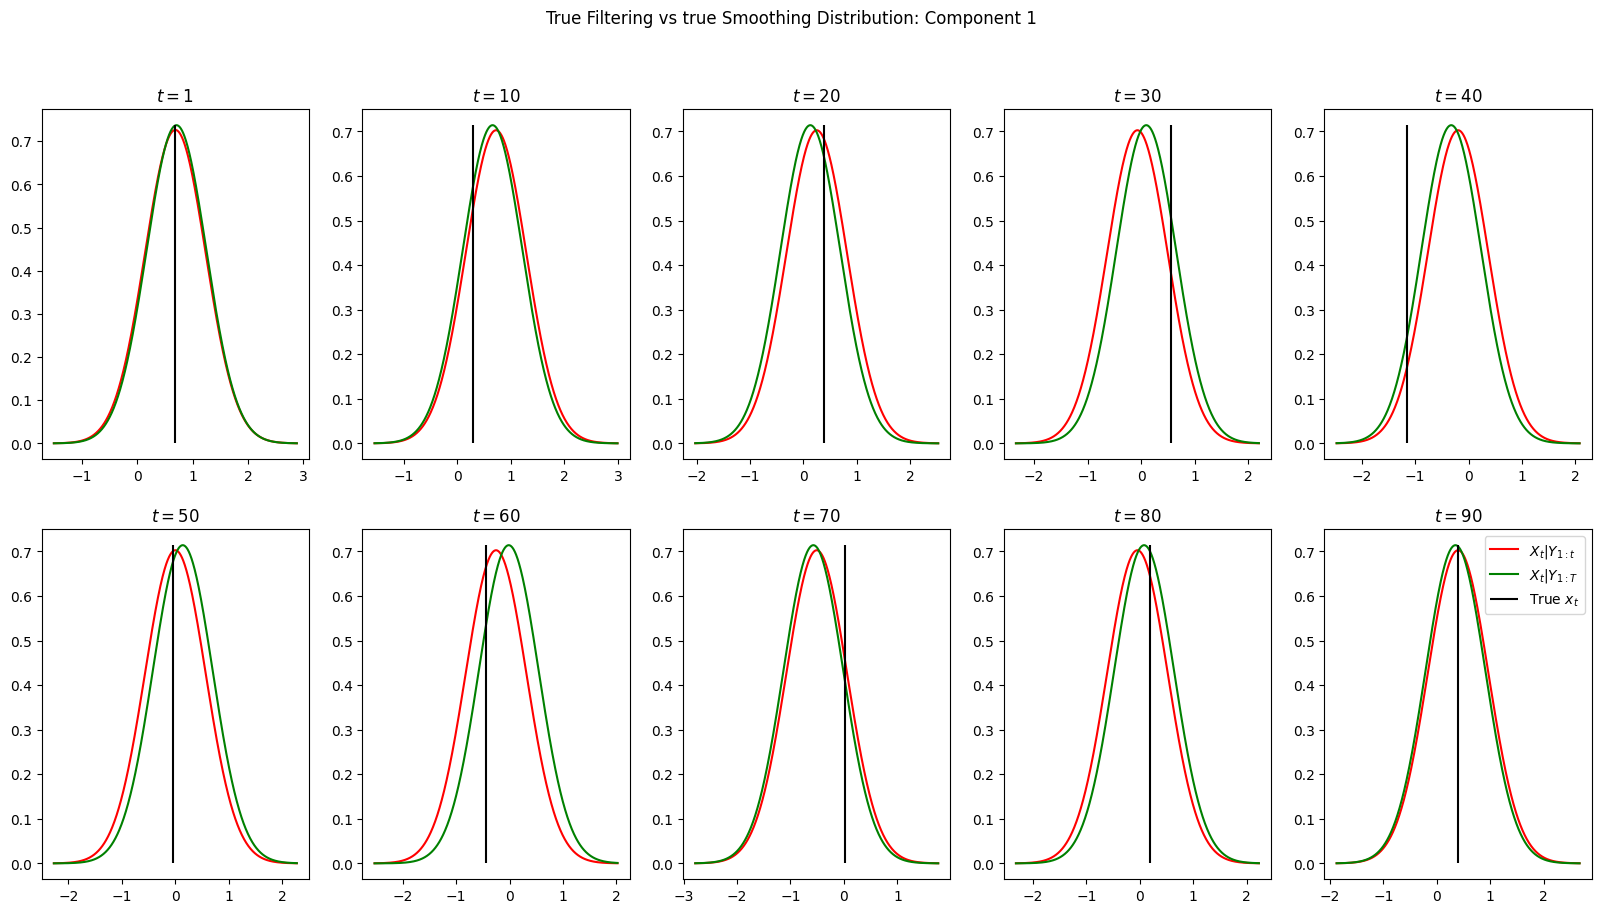

In [5]:
for j in range(1, cdssm.dimX +1):
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.ravel()

    for k, ax in enumerate(axes):
        t = obs_times[k]
        x_t_true = x[t][x[t].dtype.names[-1]].ravel()

        x_lim_lower = df_1.loc[t, f'x_t_filt_mean_{j}{ext}'] - 4. * df_1.loc[t, f'x_t_filt_std_{j}{ext}']
        x_lim_upper = df_1.loc[t, f'x_t_filt_mean_{j}{ext}'] + 4. * df_1.loc[t, f'x_t_filt_std_{j}{ext}']

        x_linsp = np.linspace(x_lim_lower, x_lim_upper, num=1000)

        filt_pdf_linsp = stats.norm.pdf(x_linsp, loc=df_1.loc[t, f'x_t_filt_mean_{j}{ext}'], scale=df_1.loc[t, f'x_t_filt_std_{j}{ext}'])
        smth_pdf_linsp = stats.norm.pdf(x_linsp, loc=df_1.loc[t, f'x_t_smth_mean_{j}{ext}'], scale=df_1.loc[t, f'x_t_smth_std_{j}{ext}'])
        y_max = np.max([np.max(filt_pdf_linsp), np.max(smth_pdf_linsp)])

        ax.plot(x_linsp, filt_pdf_linsp, '-', c='red', label=r'$X_t|Y_{1:t}$')
        ax.plot(x_linsp, smth_pdf_linsp, '-', c='green', label=r'$X_t|Y_{1:T}$')

        ax.vlines(x_t_true[j-1], ymin=0.0, ymax=y_max, colors='black', label=r'True $x_t$')
        ax.set_title(f'$t={t+1}$')
    plt.legend()
    plt.suptitle(f'True Filtering vs true Smoothing Distribution: Component {j}')
    plt.show()
    # plt.legend()
    # plt.show()

In [6]:
# d=1
# mean_or_std = 'std'

# out = df_1['x_t_smth_std_1'] - df_1['x_t_smth_std_1_pf']
# out.mean()

# Part 2: Comparison of smoothing methods for standard PFs

## Diagnostic: Run a single particle filter for particle filter used in the experiment, and evaluate the genealogy 

In [7]:
# N_genealogy = 1000
# N_FFBS_MCMC = 1000

cdssm_smc = True

if not cdssm_smc:
    fk = ssms.GuidedPF(ssm=lgssm, data=y)
    alg_1 = SMC(fk=fk, N=N_genealogy, store_history=True)
    alg_2 = SMC(fk=fk, N=N_FFBS_MCMC, store_history=True)
else:
    fk_1 = sfk.BackwardGuidedDA(cdssm=cdssm, data=y) #auxiliary_bridge_cls=axb.IntegratedDriftBrownianAuxBridge, end_pt_proposal_cls=axb.IntegratedDriftBrownianEndPointProposal)
    fk_2 = sfk.BackwardReparameterisedDA(cdssm=cdssm, data=y) #, auxiliary_bridge_cls=axb.IntegratedDriftBrownianAuxBridge, end_pt_proposal_cls=axb.IntegratedDriftBrownianEndPointProposal)
    alg_1 = CDSSM_SMC(fk=fk_1, N=N_genealogy, store_history=True)
    alg_2 = CDSSM_SMC(fk=fk_2, N=N_FFBS_MCMC, store_history=True)

alg_1_cpu = time.perf_counter()
alg_1.run()
Z_1 = alg_1.hist.backward_sampling_genealogy(N_genealogy)
alg_1_cpu = time.perf_counter() - alg_1_cpu

alg_2_cpu = time.perf_counter()
alg_2.run()
Z_2 = alg_2.hist.backward_sampling_mcmc(N_FFBS_MCMC, nsteps=1)
alg_2_cpu = time.perf_counter() - alg_2_cpu

print('Genealogy CPU time: ', alg_1_cpu)
print('FFBS-MCMC CPU time: ', alg_2_cpu)

Genealogy CPU time:  0.4478491670015501
FFBS-MCMC CPU time:  0.08816654099791776


In [8]:
# stats.kstest(sample_2, 'norm', args=(true_mu, true_std)).pvalue, stats.kstest(sample_1, 'norm', args=(true_mu, true_std)).pvalue

In [9]:
# j=1
# for t in obs_times[:-1]:

#     sample_1 = Z_1[t][Z_1[t].dtype.names[-1]]
#     sample_2 = Z_2[t][Z_2[t].dtype.names[-1]]
#     true_mu = df_1.loc[t, f'x_t_smth_mean_{j}{ext}']
#     true_std = df_1.loc[t, f'x_t_smth_std_{j}{ext}']
#     filt_mu = df_1.loc[t, f'x_t_filt_mean_{j}{ext}']
#     filt_std = df_1.loc[t, f'x_t_filt_std_{j}{ext}']
#     p_val = stats.kstest(sample_2, 'norm', args=(true_mu, true_std)).pvalue
#     print(f'Testing for t={t} KS-test p-value: {p_val}')
#     # assert p_val > 1e-8


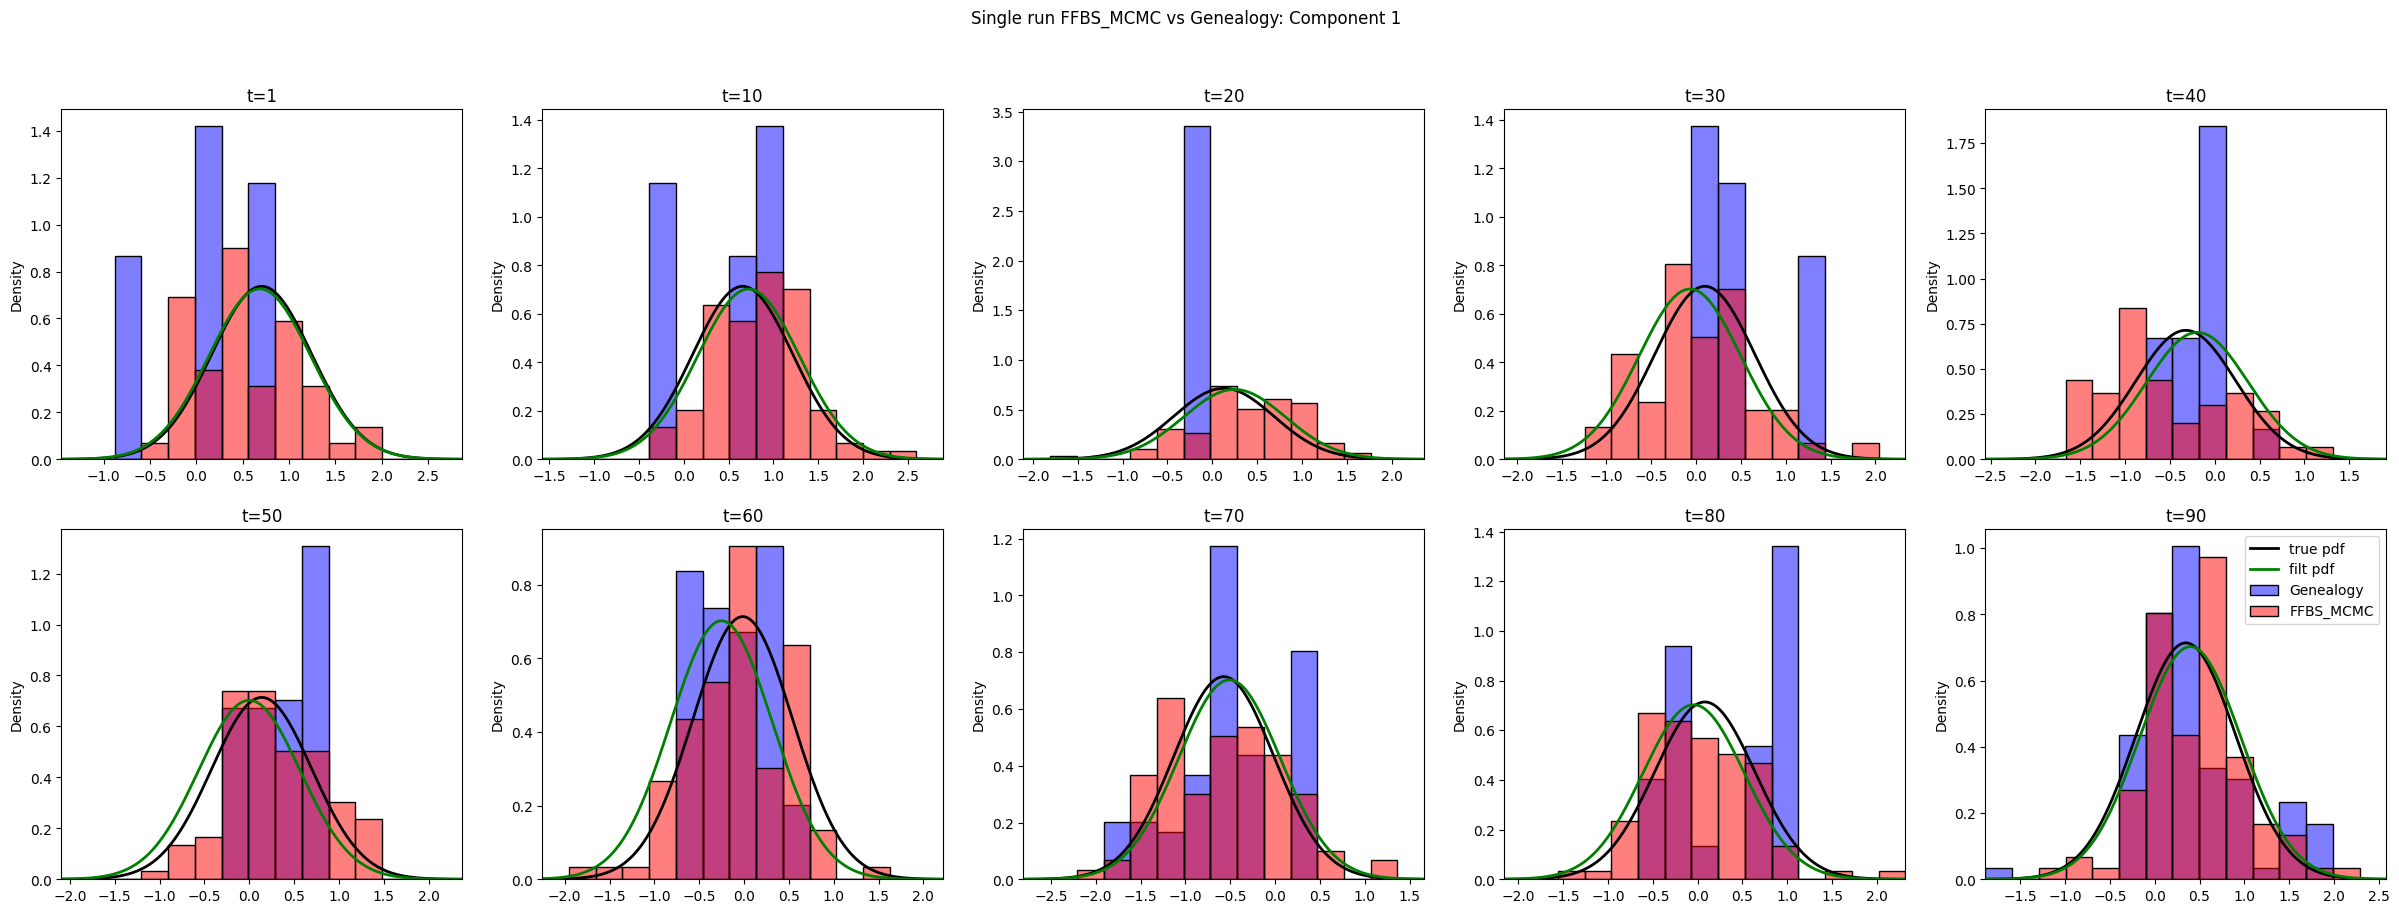

In [10]:
for j in range(1, cdssm.dimX+1):
    fig, axes = plt.subplots(2, 5, figsize=(30, 10))
    axes = axes.ravel()

    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        
        for t, ax in zip(obs_times, axes):
            
            if not cdssm_smc:
                sample_1 = Z_1[t][:, j-1]
                sample_2 = Z_2[t][:, j-1]
                # sample_1 = Z_1[t]
                # sample_2 = Z_2[t]
            else:
                if isinstance(cdssm, MvNormalCDSSM):
                    sample_1 = Z_1[t][Z_1[t].dtype.names[-1]][:, j-1]
                    sample_2 = Z_2[t][Z_2[t].dtype.names[-1]][:, j-1]
                else:
                    sample_1 = Z_1[t][Z_1[t].dtype.names[-1]]
                    sample_2 = Z_2[t][Z_2[t].dtype.names[-1]]            
            
            true_mu = df_1.loc[t, f'x_t_smth_mean_{j}{ext}']
            true_std = df_1.loc[t, f'x_t_smth_std_{j}{ext}']
            filt_mu = df_1.loc[t, f'x_t_filt_mean_{j}{ext}']
            filt_std = df_1.loc[t, f'x_t_filt_std_{j}{ext}']
            
            xmin = true_mu - 4. * true_std
            xmax = true_mu + 4. * true_std

            x_linsp = np.linspace(xmin, xmax, 1000)
            pdf = stats.norm.pdf(x_linsp, loc=true_mu, scale=true_std)
            filt_pdf = stats.norm.pdf(x_linsp, loc=filt_mu, scale=filt_std)

            # Define common bins (bin edges based on combined data)
            n_bins = 15
            bin_min = xmin  # Smallest value in both samples
            bin_max = xmax  # Largest value in both samples
            bin_width = (bin_max - bin_min)/n_bins # Set desired bin width

            bins = np.arange(bin_min, bin_max + bin_width, bin_width)  # Compute bin edges

            sns.histplot(sample_1, bins=bins, color='blue', alpha=0.5, stat="density", ax=ax, label="Genealogy")
            sns.histplot(sample_2, bins=bins, color='red', alpha=0.5, stat="density", ax=ax, label="FFBS_MCMC")

            # # Plot the true PDF
            ax.plot(x_linsp, pdf, 'k-', linewidth=2, label="true pdf")
            ax.plot(x_linsp, filt_pdf, 'g-', linewidth=2, label="filt pdf")
            
            # Formatting
            ax.set_title(f"t={t+1}")
            ax.set_xlim((xmin, xmax))

    plt.legend()
    plt.suptitle(f'Single run FFBS_MCMC vs Genealogy: Component {j}')
    # Show plot
    plt.show()


In [11]:
# n_particles_genealogy = np.array([len(np.unique(Z_1[t][Z_1[t].dtype.names[-1]]))for t in range(T)]) 
# n_particles_mcmc = np.array([len(np.unique(Z_2[t][Z_2[t].dtype.names[-1]]))for t in range(T)])

In [12]:
# np.all(n_particles_genealogy[:-1] < n_particles_genealogy[1:] + 0.01)

In [13]:
# plt.plot(np.arange(T), n_particles_genealogy, label='Genealogy', color='blue')
# plt.plot(np.arange(T), n_particles_mcmc, label='MCMC', color='red')
# plt.legend()
# plt.show()

## Genealogy of particles from filter

We take the output of the first particle filter, and we plot 
- Trajectories of the particle genealogies
- Trajectories from algorithms that enables changing ancestors

In [14]:
# if not cdssm_smc:
#     alg_3 = alg_1
# else:
#     fk_3 = sfk.BootstrapReparameterisedDA(cdssm=cdssm, data=y)
#     alg_3 = CDSSM_SMC(fk=fk_3, N=N_genealogy, store_history=True)
#     alg_3.run()

# Bs_all = alg_3.hist.compute_trajectories()
# Bs_2 = alg_3.hist.backward_sampling_mcmc_idx(N_genealogy)

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# for i in range(N_genealogy):
#     axes[0].plot(np.arange(1, T+1, dtype=np.float64), Bs_all[:, i], c='black')
#     axes[1].plot(np.arange(1, T+1, dtype=np.float64), Bs_2[:, i], c='black')
    
# axes[0].set_title('Genealogy')
# axes[1].set_title('FFBS_MCMC')
# plt.show()

In [15]:
# n_particles_ratios = [np.unique(Bs_2[idx]).shape[0]/np.unique(Bs_all[idx]).shape[0] for idx in range(T)]
# plt.plot(n_particles_ratios)
# plt.show()

## Data preprocesing

- Add true values of $E[X^2]$ to the true_vals_df (df_2)
- Add true quantile values to the true_vals_df (df_1)

In [16]:
dx = metadata['cdssm'].dimX
quantiles = np.linspace(0.05, 0.95, num=19)

for d in range(cdssm.dimX):
    df_1[f'x_t_smth_sq_{d+1}{ext}'] = df_1[f'x_t_smth_mean_{d+1}{ext}']**2 + df_1[f'x_t_smth_std_{d+1}{ext}']**2

for q in quantiles:
    q_str = str(round(q, 2))
    for d in range(cdssm.dimX):
        df_1[f'x_t_smth_q{q_str}_{d+1}{ext}'] = df_1[f'x_t_smth_mean_{d+1}{ext}'] + stats.norm.ppf(q) * df_1[f'x_t_smth_std_{d+1}{ext}']

Convert estimators of first and second moments to estimators of the std in estimators df (df_2)


In [17]:
for d in range(dx):
    for t in obs_times:
        df_2[f'x_{t}_std_est_{d+1}'] = np.sqrt(df_2[f'x_{t}_sq_est_{d+1}'] - df_2[f'x_{t}_est_{d+1}']**2)

Calculate sq errors and abs errors of estimators of the first moment ($E[X_t]$), the second moment ($E[X_t^2]$) and the std  ($\sqrt{E[X_t^2]- E[X_t]^2}$) of the marginal smoothing distributions at each time $t$:

In [18]:
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", category=[FutureWarning, pd.errors.PerformanceWarning])

for d in range(dx):
    for t in obs_times:
        df_2[f'x_{t}_est_{d+1}_se'] = (df_2[f'x_{t}_est_{d+1}'] - df_1.loc[t, f'x_t_smth_mean_{d+1}{ext}']) ** 2
        df_2[f'x_{t}_std_est_{d+1}_se'] = (df_2[f'x_{t}_std_est_{d+1}'] - df_1.loc[t,f'x_t_smth_std_{d+1}{ext}']) ** 2
        df_2[f'x_{t}_est_{d+1}_ae'] = np.sqrt(df_2[f'x_{t}_est_{d+1}_se'])
        df_2[f'x_{t}_std_est_{d+1}_ae'] = np.sqrt(df_2[f'x_{t}_std_est_{d+1}_se'])
        for q in quantiles:
            q_str = str(round(q, 2))
            df_2[f'x_{t}_q{q_str}_est_{d+1}_se'] = (df_2[f'x_{t}_q{q_str}_est_{d+1}'] - df_1.loc[t, f'x_t_smth_q{q_str}_{d+1}{ext}']) ** 2
            df_2[f'x_{t}_q{q_str}_est_{d+1}_ae'] = np.sqrt(df_2[f'x_{t}_q{q_str}_est_{d+1}_se'])

/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_4681/1580602302.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2[f'x_{t}_est_{d+1}_ae'] = np.sqrt(df_2[f'x_{t}_est_{d+1}_se'])
/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_4681/1580602302.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2[f'x_{t}_std_est_{d+1}_ae'] = np.sqrt(df_2[f'x_{t}_std_est_{d+1}_se'])
/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_4681/1580602302.py:12: PerformanceWarning: DataFrame is highly fragmented.  Thi

## Results: CPU Times of the methods

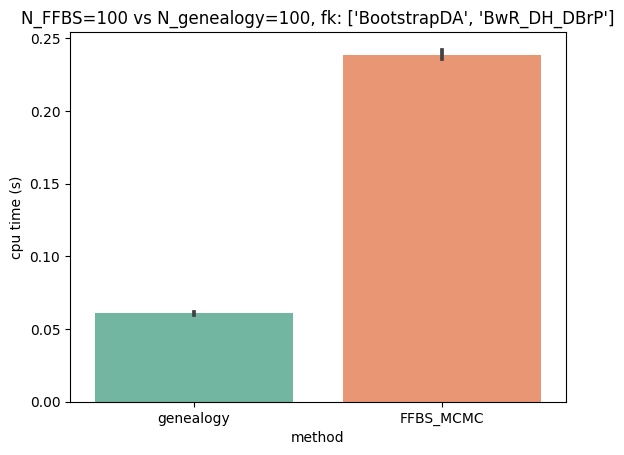

In [19]:
N_FFBS_MCMC = metadata['N_FFBS_MCMC']; N_genealogy = metadata['N_genealogy']
sns.barplot(data=df_2, x="method", y="cpu", palette="Set2")
fig, ax = plt.gcf(), plt.gca()
plt.ylabel('cpu time (s)')
plt.title(f'N_FFBS={N_FFBS_MCMC} vs N_genealogy={N_genealogy}, fk: {fks}')
plt.show()

## Results: MAE of the Estimators of the Mean and Std of the marginal smoothing distributions

In [20]:
df_2

,run_id,seed,method,fk,cpu,x_0_est_1,x_0_sq_est_1,x_0_q0.05_est_1,x_0_q0.1_est_1,x_0_q0.15_est_1,...,x_99_q0.75_est_1_se,x_99_q0.75_est_1_ae,x_99_q0.8_est_1_se,x_99_q0.8_est_1_ae,x_99_q0.85_est_1_se,x_99_q0.85_est_1_ae,x_99_q0.9_est_1_se,x_99_q0.9_est_1_ae,x_99_q0.95_est_1_se,x_99_q0.95_est_1_ae
0,0,674796,genealogy,BootstrapDA,0.026740,0.812876,0.886440,0.268649,0.268649,0.268649,...,0.000410,0.020239,0.002760,0.052540,0.012450,0.111580,0.000272,0.016484,0.000119,0.010919
3,1,3335876,genealogy,BootstrapDA,0.030278,1.374882,1.892397,1.368342,1.368342,1.368342,...,0.001809,0.042536,0.008204,0.090577,0.013832,0.117611,0.000353,0.018788,0.029953,0.173069
6,2,6268257,genealogy,BootstrapDA,0.086434,0.908536,0.843110,0.898126,0.898126,0.898126,...,0.026698,0.163397,0.051039,0.225917,0.029569,0.171956,0.031693,0.178026,0.041586,0.203927
9,3,8522066,genealogy,BootstrapDA,0.090980,0.339156,0.228634,-0.026692,-0.026692,-0.026692,...,0.000766,0.027674,0.000283,0.016837,0.005793,0.076112,0.011486,0.107173,0.000007,0.002726
12,4,11672263,genealogy,BootstrapDA,0.077724,1.303409,2.226176,0.045671,0.045671,0.045671,...,0.001058,0.032521,0.000507,0.022512,0.016317,0.127737,0.018404,0.135660,0.015631,0.125025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9203,1531,4283429150,FFBS_MCMC,BwR_DH_DBrP,0.186226,0.804454,0.988417,0.090498,0.190280,0.227837,...,0.006552,0.080946,0.023036,0.151776,0.053661,0.231649,0.025080,0.158368,0.130410,0.361123
9206,1532,4286272107,FFBS_MCMC,BwR_DH_DBrP,0.226094,0.720060,0.917082,-0.162448,0.152860,0.154741,...,0.003625,0.060211,0.000006,0.002349,0.002217,0.047089,0.013840,0.117645,0.086799,0.294616
9209,1533,4289217447,FFBS_MCMC,BwR_DH_DBrP,0.191248,0.914869,1.065624,0.128713,0.255927,0.427835,...,0.015007,0.122502,0.018194,0.134885,0.011176,0.105717,0.000109,0.010435,0.007027,0.083826
9212,1534,4291245653,FFBS_MCMC,BwR_DH_DBrP,0.232078,0.609232,0.633259,-0.186598,-0.098364,0.158100,...,0.010424,0.102098,0.001815,0.042600,0.000588,0.024244,0.018793,0.137088,0.049927,0.223443


In [21]:
series = (df_2['x_0_sq_est_1'] - df_2['x_0_est_1'] ** 2) < 0
series.sum()

21

In [22]:
df_2

,run_id,seed,method,fk,cpu,x_0_est_1,x_0_sq_est_1,x_0_q0.05_est_1,x_0_q0.1_est_1,x_0_q0.15_est_1,...,x_99_q0.75_est_1_se,x_99_q0.75_est_1_ae,x_99_q0.8_est_1_se,x_99_q0.8_est_1_ae,x_99_q0.85_est_1_se,x_99_q0.85_est_1_ae,x_99_q0.9_est_1_se,x_99_q0.9_est_1_ae,x_99_q0.95_est_1_se,x_99_q0.95_est_1_ae
0,0,674796,genealogy,BootstrapDA,0.026740,0.812876,0.886440,0.268649,0.268649,0.268649,...,0.000410,0.020239,0.002760,0.052540,0.012450,0.111580,0.000272,0.016484,0.000119,0.010919
3,1,3335876,genealogy,BootstrapDA,0.030278,1.374882,1.892397,1.368342,1.368342,1.368342,...,0.001809,0.042536,0.008204,0.090577,0.013832,0.117611,0.000353,0.018788,0.029953,0.173069
6,2,6268257,genealogy,BootstrapDA,0.086434,0.908536,0.843110,0.898126,0.898126,0.898126,...,0.026698,0.163397,0.051039,0.225917,0.029569,0.171956,0.031693,0.178026,0.041586,0.203927
9,3,8522066,genealogy,BootstrapDA,0.090980,0.339156,0.228634,-0.026692,-0.026692,-0.026692,...,0.000766,0.027674,0.000283,0.016837,0.005793,0.076112,0.011486,0.107173,0.000007,0.002726
12,4,11672263,genealogy,BootstrapDA,0.077724,1.303409,2.226176,0.045671,0.045671,0.045671,...,0.001058,0.032521,0.000507,0.022512,0.016317,0.127737,0.018404,0.135660,0.015631,0.125025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9203,1531,4283429150,FFBS_MCMC,BwR_DH_DBrP,0.186226,0.804454,0.988417,0.090498,0.190280,0.227837,...,0.006552,0.080946,0.023036,0.151776,0.053661,0.231649,0.025080,0.158368,0.130410,0.361123
9206,1532,4286272107,FFBS_MCMC,BwR_DH_DBrP,0.226094,0.720060,0.917082,-0.162448,0.152860,0.154741,...,0.003625,0.060211,0.000006,0.002349,0.002217,0.047089,0.013840,0.117645,0.086799,0.294616
9209,1533,4289217447,FFBS_MCMC,BwR_DH_DBrP,0.191248,0.914869,1.065624,0.128713,0.255927,0.427835,...,0.015007,0.122502,0.018194,0.134885,0.011176,0.105717,0.000109,0.010435,0.007027,0.083826
9212,1534,4291245653,FFBS_MCMC,BwR_DH_DBrP,0.232078,0.609232,0.633259,-0.186598,-0.098364,0.158100,...,0.010424,0.102098,0.001815,0.042600,0.000588,0.024244,0.018793,0.137088,0.049927,0.223443


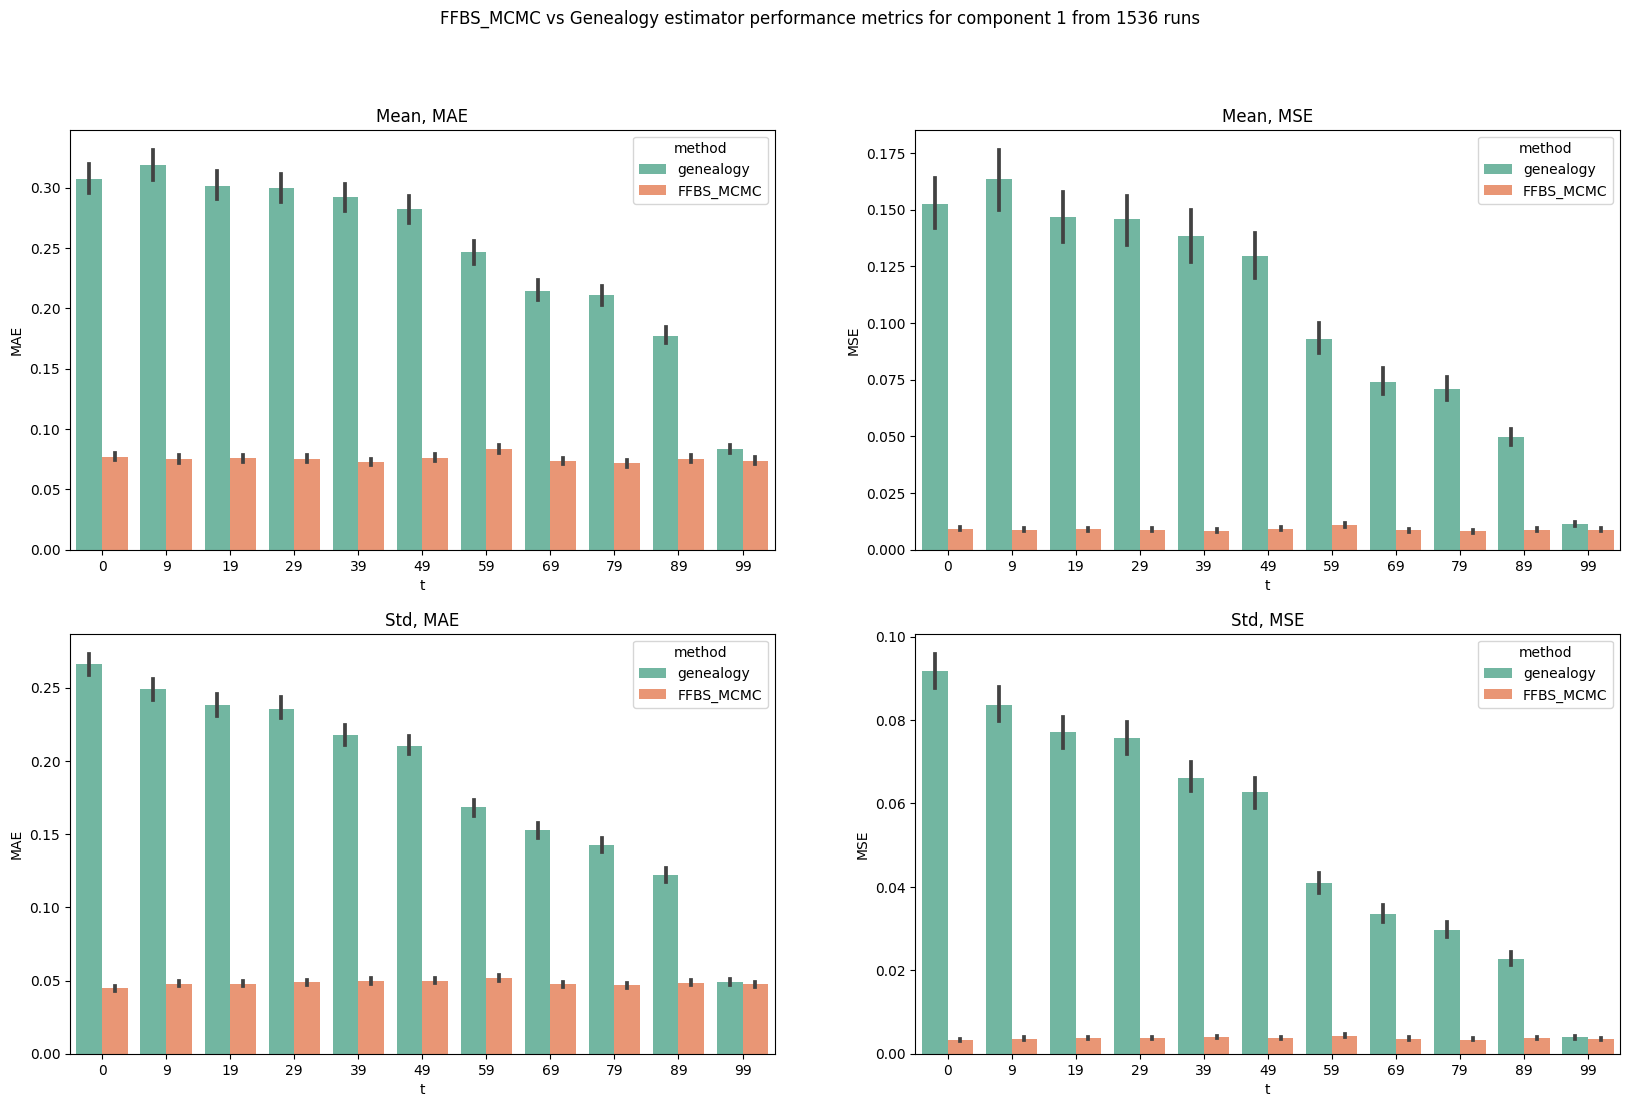

In [23]:
# with warnings.catch_warnings():
#     warnings.simplefilter("once", category=[FutureWarning, pd.errors.SettingWithCopyWarning])

for j in range(1, cdssm.dimX+1):
    obs_time_dfs = [None] * len(obs_times)

    for i, obs_time in enumerate(obs_times):
        obs_time_df_cols = ['method', 'cpu', f'x_{obs_time}_est_{j}_ae', f'x_{obs_time}_est_{j}_se', f'x_{obs_time}_std_est_{j}_ae', f'x_{obs_time}_std_est_{j}_se']
        obs_time_df = df_2[obs_time_df_cols].copy()
        obs_time_df.columns = ['method', 'cpu', 'abs_error', 'sq_error', 'abs_error_std', 'sq_error_std']
        obs_time_df['t'] = [obs_time] * obs_time_df.shape[0]
        obs_time_dfs[i] = obs_time_df
            
    plot_df = pd.concat(obs_time_dfs)

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.ravel()

    cols = ['abs_error', 'sq_error', 'abs_error_std', 'sq_error_std']
    y_labels = ['MAE', 'MSE', 'MAE', 'MSE']
    titles = ['Mean, MAE', 'Mean, MSE', 'Std, MAE', 'Std, MSE']

    for i, ax in enumerate(axes):
        sns.barplot(data=plot_df, x="t", y=cols[i], hue="method", ax=ax, palette="Set2")
        ax.set_title(titles[i])
        ax.set_ylabel(y_labels[i])

    plt.suptitle(f'FFBS_MCMC vs Genealogy estimator performance metrics for component {j} from {nruns} runs')
    plt.show()

# Plot for poster

In [26]:
plot_df

,method,cpu,abs_error,sq_error,abs_error_std,sq_error_std,t
0,genealogy,0.026740,0.107362,0.011527,0.066165,0.004378,0
3,genealogy,0.030278,0.669368,0.448053,0.495431,0.245452,0
6,genealogy,0.086434,0.203021,0.041218,0.408277,0.166690,0
9,genealogy,0.090980,0.366359,0.134219,0.204157,0.041680,0
12,genealogy,0.077724,0.597895,0.357478,0.184941,0.034203,0
...,...,...,...,...,...,...,...
9203,FFBS_MCMC,0.186226,0.018273,0.000334,0.090410,0.008174,99
9206,FFBS_MCMC,0.226094,0.123071,0.015146,0.051739,0.002677,99
9209,FFBS_MCMC,0.191248,0.099287,0.009858,0.022538,0.000508,99
9212,FFBS_MCMC,0.232078,0.033973,0.001154,0.002490,0.000006,99


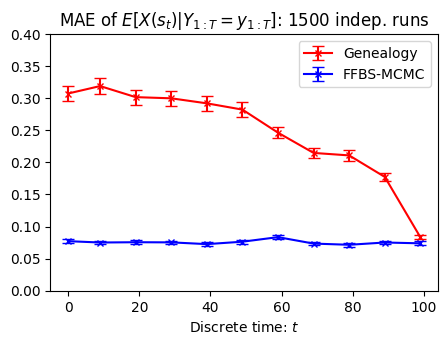

In [30]:
plot_df_genealogy = plot_df[plot_df['method'] == 'genealogy']
plot_df_ffbs = plot_df[plot_df['method'] == 'FFBS_MCMC']

cols = ['abs_error', 't']
plot_df_genealogy = plot_df_genealogy[cols]
plot_df_ffbs = plot_df_ffbs[cols]
n_samples = plot_df_genealogy.shape[0] // 11

genealogy_mean = plot_df_genealogy.groupby('t').mean()
genealogy_err= stats.norm.ppf(0.975) * plot_df_genealogy.groupby('t').std() / np.sqrt(n_samples)

ffbs_mean = plot_df_ffbs.groupby('t').mean()
ffbs_err= stats.norm.ppf(0.975) * plot_df_ffbs.groupby('t').std() / np.sqrt(n_samples)

fig, ax = plt.subplots(figsize=(5, 10/3))

ax.errorbar(genealogy_mean.index, genealogy_mean['abs_error'], yerr=genealogy_err.values.ravel(), fmt='x-', label='Genealogy', color='red', markersize=5, capsize=4)
ax.errorbar(ffbs_mean.index, ffbs_mean['abs_error'], yerr=ffbs_err.values.ravel(), fmt='x-', label='FFBS-MCMC', color='blue', markersize=5, capsize=4)
ax.set_title(r'MAE of $E[X(s_t)|Y_{1:T}=y_{1:T}]$: 1500 indep. runs')
ax.set_xlabel(r'Discrete time: $t$')
ax.legend()
ax.set_ylim((0, 0.4))

plt.savefig(f'../poster/results_small.pdf', bbox_inches='tight')
plt.show()

/Users/chris_stanton/Library/CloudStorage/OneDrive-UniversityCollegeLondon/PhD/particles-cdssm/venv/diffusions/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/chris_stanton/Library/CloudStorage/OneDrive-UniversityCollegeLondon/PhD/particles-cdssm/venv/diffusions/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/chris_stanton/Library/CloudStorage/OneDrive-UniversityCollegeLondon/PhD/particles-cdssm/venv/diffusions/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group 

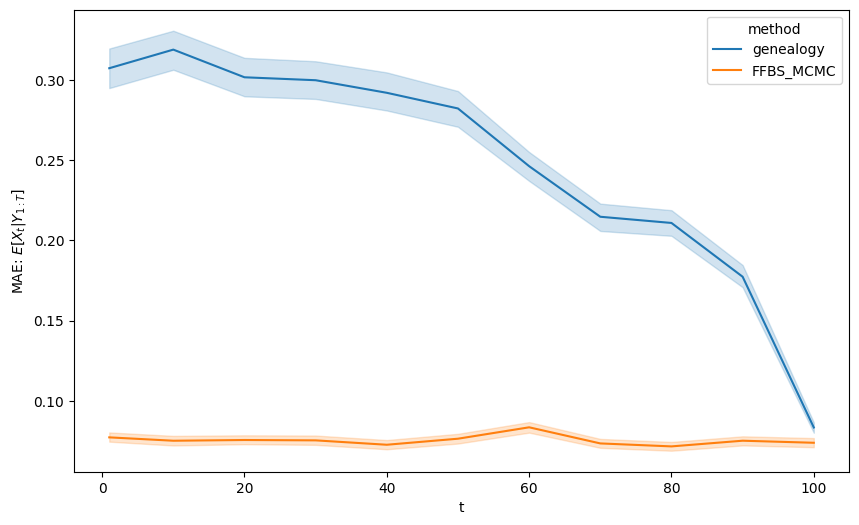

In [ ]:
# with warnings.catch_warnings():
#     warnings.simplefilter("once", category=[FutureWarning, pd.errors.SettingWithCopyWarning])

for j in range(1, cdssm.dimX+1):
    obs_time_dfs = [None] * len(obs_times)

    for i, obs_time in enumerate(obs_times):
        obs_time_df_cols = ['method', 'cpu', f'x_{obs_time}_est_{j}_ae', f'x_{obs_time}_std_est_{j}_ae']
        obs_time_df = df_2[obs_time_df_cols].copy()
        obs_time_df.columns = ['method', 'cpu', 'abs_error', 'abs_error_std']
        obs_time_df['t'] = [obs_time] * obs_time_df.shape[0]
        obs_time_df['t'] = obs_time_df['t'] + 1

        obs_time_dfs[i] = obs_time_df
            
    plot_df = pd.concat(obs_time_dfs)

    fig, axes = plt.subplots(1, 1, figsize=(10, 6))

    cols = ['abs_error', 'sq_error', 'abs_error_std', 'sq_error_std']
    y_labels = ['MAE', 'MSE', 'MAE', 'MSE']
    titles = ['Mean, MAE', 'Mean, MSE', 'Std, MAE', 'Std, MSE']

    sns.lineplot(data=plot_df, x="t", y='abs_error', hue="method", ax=axes)
        # ax.set_title(titles[i])
        # ax.set_ylabel(y_labels[i])
    axes.set_ylabel(r'MAE: $E[X_t|Y_{1:T}]$')
    plt.show()

## Results: Estimators of Quantiles